# EV presence classification

This notebook is the readable report for the cached, leakage-safe experiment run. It does not tune models or open the held-out test split. Model selection, freezing, and the one-time test evaluation are performed by `run_classification.py`; this notebook validates and displays those immutable artifacts.

The target is a conservative temporal weak label derived from project-span dates, which have not been confirmed as EV commissioning dates. Predictions are evidence of charger-like load behavior rather than verified ownership.

In [1]:
from pathlib import Path
import json
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display

ROOT = Path.cwd()
if not (ROOT / 'ev_classification').exists():
    ROOT = ROOT.parent
EV = ROOT / 'ev_classification'
OUT = EV / 'classification_output'

def read_json(name):
    return json.loads((OUT / name).read_text())

manifest = read_json('run_manifest.json')
audit = read_json('audit.json')
leaderboard = pd.DataFrame([{
    'id': row['id'], 'family': row['family'],
    'customers': row['metrics']['customers_or_weeks'],
    'pr_auc': row['metrics']['pr_auc'],
    'balanced_accuracy': row['metrics']['balanced_accuracy'],
    'f1': row['metrics']['f1'], 'brier': row['metrics']['brier'],
    'runtime_seconds': row['runtime'], 'status': 'validation',
} for row in read_json('leaderboard.json')])
display(Markdown(f"**Run identity:** `{manifest['run_identity']}`  \\n**Source identity:** `{manifest['source']['hash']}`  \\n**Test status:** `{manifest['test_status']}`"))

**Run identity:** `58bd932a3b44b9669cfd358fa2160175774da912711031976d3f792238b783c6`  \n**Source identity:** `69a33762f866aeca210389e6866fedd3aa01c65af74cfe72b4225c92f2658fbc`  \n**Test status:** `evaluated_once`

## Evaluation contract

Customers are permanently assigned to development, validation, or final test; all weeks from a customer stay in one split. Only rows with `eligible_for_supervised_training == 1` and a known temporal target can affect fitting, tuning, calibration, or supervised metrics. The primary comparison uses at most the 12 most recent state-appropriate weeks and requires two weeks of history. Customer average precision is the selection metric, with paired customer bootstrap intervals.

In [2]:
split = pd.read_parquet(OUT / 'split_manifest.parquet')
assert split['gp_nr'].is_unique
assert set(split['split']) == {'development', 'validation', 'test'}
cohorts = {name: pd.read_parquet(OUT / f'cohort_{name}.parquet') for name in ('development', 'validation', 'test')}
summary = pd.DataFrame({
    name: {
        'all customers': int((split['split'] == name).sum()),
        'comparison customers': int(frame['status'].eq('ok').sum()),
        'comparison positives': int(frame.loc[frame['status'].eq('ok'), 'target'].sum()),
        'insufficient history': int(frame['status'].eq('insufficient_history').sum()),
    } for name, frame in cohorts.items()
}).T
display(summary)
display(pd.Series(audit['target_counts'], name='eligible labelled weeks').to_frame())

,all customers,comparison customers,comparison positives,insufficient history
development,199,183,26,16
validation,66,61,9,5
test,66,61,9,5


,eligible labelled weeks
0.0,22424
1.0,3050


## Literature-informed evidence

Published work motivates sustained kW-level duration, repeated charging levels, paired edges, and event-shape similarity, while warning that ordinary household loads can create false positives. The experiments therefore compare transparent event detectors with compact logistic regression and bounded LightGBM models. Numerical thresholds are tuned only on development and validation customers. See [Hoffmann et al. (2019)](https://sintef.brage.unit.no/sintef-xmlui/bitstream/handle/11250/2618624/Hoffmann%2BAutomated%2Bdetection%2Bof%2Belectric%2Bvehicles%2Bin.pdf?sequence=2), [Li et al. (2024)](https://doi.org/10.1016/j.epsr.2024.110789), [Hangawatta et al. (2025)](https://doi.org/10.1016/j.segan.2025.101903), [Figueiredo et al. (2020)](https://doi.org/10.1016/j.apenergy.2020.114949), and the [2022 SmartGridComm study](https://doi.org/10.1109/SmartGridComm52983.2022.9961024).

,id,family,customers,pr_auc,balanced_accuracy,f1,brier,runtime_seconds,status
0,E12_repeated_level,repeat,61,0.648544,0.809829,0.516129,0.606959,7.494835,validation
1,E10_sustained_block,block,61,0.529130,0.792735,0.538462,0.623052,81.786684,validation
2,E20_lgbm_compact,LightGBM compact,61,0.521141,0.800214,0.500000,0.104201,8.377864,validation
3,E22_lgbm_shape,LightGBM shape,61,0.504619,0.785256,0.600000,0.106960,18.999789,validation
4,E21_lgbm_events,LightGBM events,61,0.469434,0.800214,0.500000,0.106448,30.056848,validation
5,E24_calibration,calibration,61,0.414980,0.829060,0.551724,0.115663,6.607713,validation
6,E02_logistic,logistic,61,0.414980,0.829060,0.551724,0.115663,5.847836,validation
7,E11_plateau_edges,plateau,61,0.320156,0.667735,0.358974,0.335547,6.933764,validation
8,E01_dummy,dummy,61,0.147541,0.500000,0.257143,0.125811,5.165004,validation


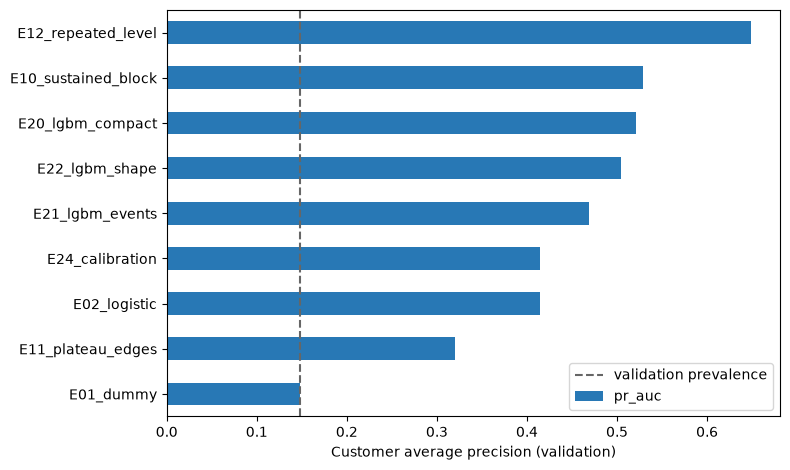

In [3]:
columns = ['id', 'family', 'customers', 'pr_auc', 'balanced_accuracy', 'f1', 'brier', 'runtime_seconds', 'status']
display(leaderboard[columns].sort_values('pr_auc', ascending=False).reset_index(drop=True))
plot = leaderboard.sort_values('pr_auc')
ax = plot.plot.barh(x='id', y='pr_auc', legend=False, figsize=(8, 4.8), color='#2878b5')
ax.axvline(audit['splits']['validation']['primary_positive'] / audit['splits']['validation']['primary_customers'], color='0.4', ls='--', label='validation prevalence')
ax.set(xlabel='Customer average precision (validation)', ylabel='')
ax.legend()
plt.tight_layout()
plt.show()

## Validation decision

Repeated-level evidence has the highest point estimate, but its paired improvement over the compact logistic model crosses zero. Under the predeclared simpler-wins tie rule, `E02_logistic` remains the champion. E13 and E14 were skipped after two consecutive heuristic extensions failed to establish an improvement beyond paired uncertainty. LightGBM event and shape features also remained within uncertainty and added complexity.

In [4]:
champion = read_json('champion.json')
freeze_path = OUT / 'final_freeze.json'
assert freeze_path.exists(), 'Run the freeze stage before executing the final report notebook.'
freeze = read_json('final_freeze.json')
assert freeze['selected'] == champion['id']
display(Markdown(f"**Frozen pipeline:** `{freeze['selected']}`  \\n**Freeze hash:** `{freeze['freeze_hash']}`  \\n**Stop reason:** {freeze['stop_reason']}"))
display(pd.DataFrame(read_json('date_sensitivity.json')['result'])[['definition', 'customers', 'positive_customers', 'unknown_eligible_weeks']])

**Frozen pipeline:** `E02_logistic`  \n**Freeze hash:** `ba19a71cae403a43c70de54f9c217642f2bdbfc95c8abffcca19e240ac275c66`  \n**Stop reason:** Major heuristic and LightGBM families evaluated; prefer simpler pipelines within paired AP uncertainty.

,definition,customers,positive_customers,unknown_eligible_weeks
0,primary,61,9,2
1,early_late_fields,61,9,2
2,washout_7_days,61,9,3
3,washout_28_days,61,9,6


In [5]:
test_metrics = read_json('final_test/metrics_test.json')
rows = []
for experiment, values in test_metrics.items():
    rows.append({'experiment': experiment, **values['customer']})
test_table = pd.DataFrame(rows).sort_values('pr_auc', ascending=False)
display(Markdown('## One-time held-out test'))
display(test_table[['experiment', 'customers_or_weeks', 'positives', 'pr_auc', 'balanced_accuracy', 'f1', 'recall', 'precision', 'brier']])
selected_metrics = test_metrics[freeze['selected']]
display(Markdown(f"The frozen `{freeze['selected']}` pipeline has test customer AP **{selected_metrics['customer']['pr_auc']:.3f}** with a 95% customer-bootstrap interval of **{selected_metrics['ci95']['pr_auc'][0]:.3f}–{selected_metrics['ci95']['pr_auc'][1]:.3f}**."))

## One-time held-out test

,experiment,customers_or_weeks,positives,pr_auc,balanced_accuracy,f1,recall,precision,brier
2,E10_sustained_block,61,9,0.284827,0.551282,0.250000,0.333333,0.200000,0.622789
0,E02_logistic,61,9,0.254576,0.597222,0.307692,0.444444,0.235294,0.123753
1,E01_dummy,61,9,0.147541,0.500000,0.257143,1.000000,0.147541,0.125794


The frozen `E02_logistic` pipeline has test customer AP **0.255** with a 95% customer-bootstrap interval of **0.085–0.577**.

## Recommendation and limitations

Use the frozen compact logistic pipeline as an interpretable research baseline and retain its weekly scores as review evidence. Treat insufficient-history cases as abstentions. Unknown and source-excluded rows are scored only in the separately marked exploratory output.

The labelled cohort is small, project dates are uncertain, and only a subset of source customers has usable meter history. Heat pumps, boilers, and other sustained loads can resemble charging; PV and batteries can hide it. The selected threshold was optimized on validation customers, so deployment to a different population needs fresh calibration and prospective verification.